# Algoritmo Genético - Recriação de Imagem (Girl with a Pearl Earring)
Este notebook implementa a base (baseline) do Algoritmo Genético para recriar a imagem com 100 triângulos.

In [ ]:
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt
import os
 
# Parametros da imagem (baseada no PDF)
WIDTH = 300
HEIGHT = 400
NUM_TRIANGLES = 100

## 1. Funções Base (Cromossoma e Renderização)

In [ ]:
def load_target_image(filepath):
    """Carrega a imagem de referência convertida para RGB."""
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Imagem {filepath} não encontrada!")
    img = cv2.imread(filepath)
    img = cv2.resize(img, (WIDTH, HEIGHT))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

def create_random_triangle(target_img=None):
    """Gera um triângulo com vértices e cor aleatórios (RGB + Alpha)."""
    cx, cy = random.randint(0, WIDTH - 1), random.randint(0, HEIGHT - 1)
    size = random.randint(10, 150)
    if target_img is not None:
        r, g, b = target_img[cy, cx]
        color = (int(r), int(g), int(b))
    else:
        color = (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255))
    return {
        'p1': (np.clip(cx + random.randint(-size, size), 0, WIDTH), np.clip(cy + random.randint(-size, size), 0, HEIGHT)),
        'p2': (np.clip(cx + random.randint(-size, size), 0, WIDTH), np.clip(cy + random.randint(-size, size), 0, HEIGHT)),
        'p3': (np.clip(cx + random.randint(-size, size), 0, WIDTH), np.clip(cy + random.randint(-size, size), 0, HEIGHT)),
        'color': color,
        'alpha': random.uniform(0.05, 0.4)
    }

def create_random_individual(target_img=None):
    """Gera um indivíduo composto por 100 triângulos."""
    return [create_random_triangle(target_img) for _ in range(NUM_TRIANGLES)]

def render_individual(individual):
    """Desenha os triângulos numa tela em branco (RGB)."""
    canvas = np.zeros((HEIGHT, WIDTH, 3), dtype=np.uint8)
    for tri in individual:
        pts = np.array([tri['p1'], tri['p2'], tri['p3']], np.int32)
        pts = pts.reshape((-1, 1, 2))
        color = tri['color']
        alpha = tri['alpha']
        
        overlay = canvas.copy()
        cv2.fillPoly(overlay, [pts], color)
        cv2.addWeighted(overlay, alpha, canvas, 1 - alpha, 0, canvas)
    return canvas


## 2. Operadores Genéticos e Fitness

In [3]:
def calculate_fitness(rendered, target):
    """Calcula o Root Mean Squared Error (Quanto menor, melhor)"""
    diff = rendered.astype(np.float32) - target.astype(np.float32)
    sq_diff = np.square(diff)
    mse = np.mean(sq_diff)
    return np.sqrt(mse)

def mutate(individual, target_img=None, mutation_rate=0.04):
    """Mutação com pequenos e grandes saltos (Fine-tuning VS Exploração)."""
    new_individual = []
    for tri in individual:
        new_tri = tri.copy()
        step_pos = 5 if random.random() < 0.8 else 30
        step_col = 10 if random.random() < 0.8 else 60
        if random.random() < mutation_rate:
            new_tri['p1'] = (np.clip(new_tri['p1'][0] + random.randint(-step_pos, step_pos), 0, WIDTH), np.clip(new_tri['p1'][1] + random.randint(-step_pos, step_pos), 0, HEIGHT))
        if random.random() < mutation_rate:
            new_tri['p2'] = (np.clip(new_tri['p2'][0] + random.randint(-step_pos, step_pos), 0, WIDTH), np.clip(new_tri['p2'][1] + random.randint(-step_pos, step_pos), 0, HEIGHT))
        if random.random() < mutation_rate:
            new_tri['p3'] = (np.clip(new_tri['p3'][0] + random.randint(-step_pos, step_pos), 0, WIDTH), np.clip(new_tri['p3'][1] + random.randint(-step_pos, step_pos), 0, HEIGHT))
        if random.random() < mutation_rate:
            r = np.clip(new_tri['color'][0] + random.randint(-step_col, step_col), 0, 255)
            g = np.clip(new_tri['color'][1] + random.randint(-step_col, step_col), 0, 255)
            b = np.clip(new_tri['color'][2] + random.randint(-step_col, step_col), 0, 255)
            new_tri['color'] = (int(r), int(g), int(b))
        if random.random() < (mutation_rate * 0.5):
            new_tri['alpha'] = np.clip(new_tri['alpha'] + random.uniform(-0.1, 0.1), 0.05, 0.6)
        if random.random() < (mutation_rate * 0.4):
            cx = (new_tri['p1'][0] + new_tri['p2'][0] + new_tri['p3'][0]) / 3
            cy = (new_tri['p1'][1] + new_tri['p2'][1] + new_tri['p3'][1]) / 3
            new_tri['p1'] = (int(cx + (new_tri['p1'][0] - cx)*0.8), int(cy + (new_tri['p1'][1] - cy)*0.8))
            new_tri['p2'] = (int(cx + (new_tri['p2'][0] - cx)*0.8), int(cy + (new_tri['p2'][1] - cy)*0.8))
            new_tri['p3'] = (int(cx + (new_tri['p3'][0] - cx)*0.8), int(cy + (new_tri['p3'][1] - cy)*0.8))
        if random.random() < (mutation_rate * 0.05):
            new_tri = create_random_triangle(target_img)
        new_individual.append(new_tri)
    return new_individual

def crossover(p1, p2):
    """Crossover de 1 Ponto (Evita destruir hierarquias globais das camadas)."""
    split = random.randint(0, NUM_TRIANGLES)
    return p1[:split] + p2[split:]


## 3. Ciclo Evolutivo

In [4]:
def evolve(target_img, pop_size=50, generations=5000, mutation_rate=0.01):
    print("Inicializando população...")
    population = [create_random_individual(target_img) for _ in range(pop_size)]
    best_fitness_history = []
    
    for gen in range(generations):
        fitnesses = []
        for ind in population:
            rend = render_individual(ind)
            fit = calculate_fitness(rend, target_img)
            fitnesses.append(fit)
            
        sorted_indices = np.argsort(fitnesses)
        population = [population[i] for i in sorted_indices]
        current_best_fit = fitnesses[sorted_indices[0]]
        best_fitness_history.append(current_best_fit)
        
        elite_size = int(pop_size * 0.1)
        new_population = population[:elite_size]
        
        while len(new_population) < pop_size:
            tournament_size = 7
            tourn1 = random.sample(population[:int(pop_size*0.5)], tournament_size)
            tourn2 = random.sample(population[:int(pop_size*0.5)], tournament_size)
            p1 = tourn1[0]
            p2 = tourn2[0]
            child = crossover(p1, p2)
            child = mutate(child, target_img, mutation_rate=0.06)
            new_population.append(child)
            
        population = new_population
        
        if gen % 10 == 0 or gen == generations - 1:
            print(f"Geração {gen:04d} | Melhor RMSE: {current_best_fit:.2f}")
                
    return population[0], best_fitness_history


## 4. Teste e Visualização

Treino em progresso...
Inicializando população...
Geração 0000 | Melhor RMSE: 72.77
Geração 0010 | Melhor RMSE: 58.74
Geração 0020 | Melhor RMSE: 52.69
Geração 0030 | Melhor RMSE: 49.26
Geração 0040 | Melhor RMSE: 46.64
Geração 0050 | Melhor RMSE: 45.66
Geração 0060 | Melhor RMSE: 43.95
Geração 0070 | Melhor RMSE: 43.24
Geração 0080 | Melhor RMSE: 42.58
Geração 0090 | Melhor RMSE: 41.53
Geração 0100 | Melhor RMSE: 40.78
Geração 0110 | Melhor RMSE: 39.79
Geração 0120 | Melhor RMSE: 39.40
Geração 0130 | Melhor RMSE: 38.88
Geração 0140 | Melhor RMSE: 38.49
Geração 0150 | Melhor RMSE: 38.05
Geração 0160 | Melhor RMSE: 37.74
Geração 0170 | Melhor RMSE: 37.45
Geração 0180 | Melhor RMSE: 37.25
Geração 0190 | Melhor RMSE: 36.83
Geração 0200 | Melhor RMSE: 36.17
Geração 0210 | Melhor RMSE: 35.76
Geração 0220 | Melhor RMSE: 35.61
Geração 0230 | Melhor RMSE: 35.42
Geração 0240 | Melhor RMSE: 34.84
Geração 0250 | Melhor RMSE: 34.70
Geração 0260 | Melhor RMSE: 34.35
Geração 0270 | Melhor RMSE: 33.9

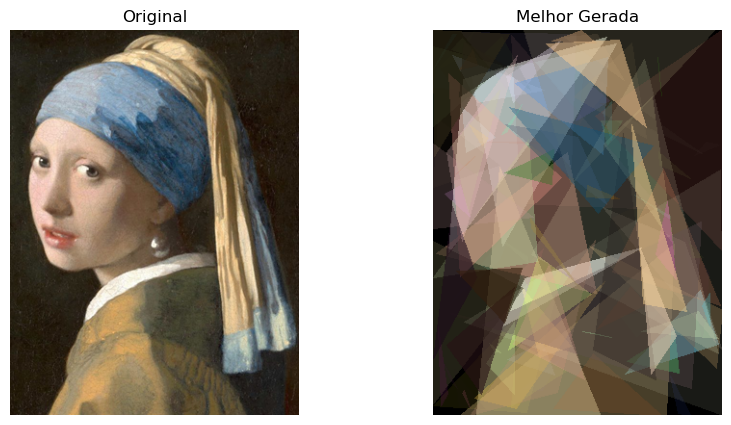

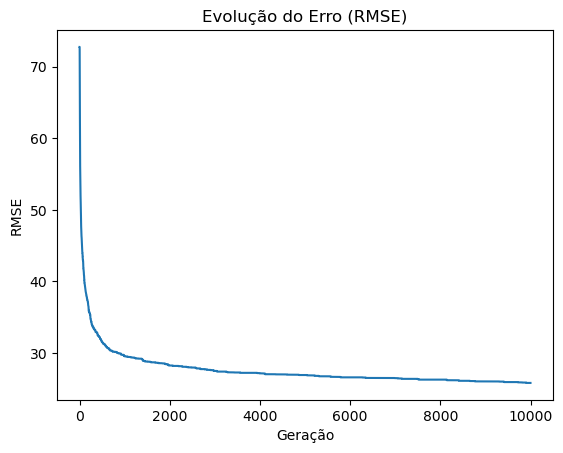

In [5]:
try:
    target = load_target_image("girl_pearl_earing.png")
    
    # Correr para confirmar que funciona
    print("Treino em progresso...")
    best_ind, history = evolve(target, pop_size=100, generations=10000, mutation_rate=0.05)
    best_rend = render_individual(best_ind)
    
    # Mostrar imagem original VS Imagem gerada lado a lado no notebook
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    ax1.imshow(target)
    ax1.set_title("Original")
    ax1.axis('off')
    
    ax2.imshow(best_rend)
    ax2.set_title("Melhor Gerada")
    ax2.axis('off')
    
    plt.show()
    
    # Mostrar evolução do erro
    plt.plot(history)
    plt.title("Evolução do Erro (RMSE)")
    plt.xlabel("Geração")
    plt.ylabel("RMSE")
    plt.show()
except Exception as e:
    print("Erro:", e)